In [1]:
from pathlib import Path
import random
import numpy as np
import torch
import torch.nn as nn

from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms

from sklearn.model_selection import train_test_split

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# Device
device = torch.device("cpu")

# Training configuration
NUM_CLASSES = 4
BATCH_SIZE = 16
EPOCHS = 10
LEARNING_RATE = 0.0001

print("Device:", device)
print("Epochs:", EPOCHS)
print("Batch size:", BATCH_SIZE)

Device: cpu
Epochs: 10
Batch size: 16


In [2]:
PROJECT_ROOT = Path.cwd().parent.parent
DATA_DIR = PROJECT_ROOT / "ml" / "data" / "processed"

TRAIN_DIR = DATA_DIR / "Training"
TEST_DIR = DATA_DIR / "Testing"

# ResNet-18 pretrained weights use ImageNet normalization.
# The images are already resized to 224x224 RGB.
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

full_train_dataset = datasets.ImageFolder(
    root=TRAIN_DIR,
    transform=transform
)

test_dataset = datasets.ImageFolder(
    root=TEST_DIR,
    transform=transform
)

print("Class mapping:", full_train_dataset.class_to_idx)
print("Training samples:", len(full_train_dataset))
print("Test samples:", len(test_dataset))

Class mapping: {'glioma': 0, 'meningioma': 1, 'notumor': 2, 'pituitary': 3}
Training samples: 5429
Test samples: 1584


In [3]:
indices = np.arange(len(full_train_dataset))
labels = np.array(full_train_dataset.targets)

train_indices, val_indices = train_test_split(
    indices,
    test_size=0.20,
    random_state=SEED,
    stratify=labels
)

train_dataset = Subset(full_train_dataset, train_indices)
val_dataset = Subset(full_train_dataset, val_indices)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0
)

print("Training samples:", len(train_dataset))
print("Validation samples:", len(val_dataset))
print("Test samples:", len(test_dataset))
print("Training batches:", len(train_loader))
print("Validation batches:", len(val_loader))

Training samples: 4343
Validation samples: 1086
Test samples: 1584
Training batches: 272
Validation batches: 68


In [4]:
from torchvision.models import resnet18, ResNet18_Weights

weights = ResNet18_Weights.DEFAULT

model = resnet18(weights=weights)

# Replace the final fully connected layer
in_features = model.fc.in_features
model.fc = nn.Linear(in_features, NUM_CLASSES)

model = model.to(device)

print("ResNet-18 loaded with pretrained ImageNet weights.")
print("Classifier:", model.fc)
print("Device:", device)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to C:\Users\Kanak/.cache\torch\hub\checkpoints\resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:16<00:00, 2.86MB/s]


ResNet-18 loaded with pretrained ImageNet weights.
Classifier: Linear(in_features=512, out_features=4, bias=True)
Device: cpu


In [5]:
# Freeze all pretrained parameters
for param in model.parameters():
    param.requires_grad = False

# Unfreeze the final classification layer
for param in model.fc.parameters():
    param.requires_grad = True

criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    model.fc.parameters(),
    lr=LEARNING_RATE
)

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(
    p.numel() for p in model.parameters()
    if p.requires_grad
)

print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")
print("Loss:", criterion)
print("Optimizer:", optimizer)

Total parameters: 11,178,564
Trainable parameters: 2,052
Loss: CrossEntropyLoss()
Optimizer: Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.0001
    maximize: False
    weight_decay: 0
)


In [6]:
images, labels = next(iter(train_loader))
images = images.to(device)

model.eval()

with torch.no_grad():
    outputs = model(images)

print("Input shape:", images.shape)
print("Output shape:", outputs.shape)
print("Expected output shape:", (images.shape[0], NUM_CLASSES))

Input shape: torch.Size([16, 3, 224, 224])
Output shape: torch.Size([16, 4])
Expected output shape: (16, 4)


In [7]:
from pathlib import Path
import copy
import time
import json
import torch

# ==========================================
# 1. OUTPUT DIRECTORIES
# ==========================================

PROJECT_ROOT = Path.cwd().parent.parent

CHECKPOINT_DIR = PROJECT_ROOT / "ml" / "results" / "checkpoints"
METRICS_DIR = PROJECT_ROOT / "ml" / "results" / "metrics"

CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)
METRICS_DIR.mkdir(parents=True, exist_ok=True)

CHECKPOINT_PATH = CHECKPOINT_DIR / "resnet18_best.pth"
HISTORY_PATH = METRICS_DIR / "resnet18_training_history.json"


# ==========================================
# 2. CLASS MAPPING
# ==========================================

# Use the original ImageFolder dataset, not its Subset
class_to_idx = full_train_dataset.class_to_idx

print("Class mapping:", class_to_idx)


# ==========================================
# 3. INITIALIZE TRACKING
# ==========================================

best_val_accuracy = 0.0
best_epoch = 0

best_model_state = copy.deepcopy(model.state_dict())

history = {
    "train_loss": [],
    "train_accuracy": [],
    "val_loss": [],
    "val_accuracy": []
}


# ==========================================
# 4. TRAINING LOOP
# ==========================================

for epoch in range(EPOCHS):

    start_time = time.time()

    # --------------------------------------
    # TRAINING
    # --------------------------------------

    # Keep frozen backbone and BatchNorm layers
    # in evaluation mode; train only the FC layer.
    model.eval()
    model.fc.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)

        predictions = outputs.argmax(dim=1)

        correct += (predictions == labels).sum().item()
        total += labels.size(0)

    train_loss = running_loss / total
    train_accuracy = correct / total


    # --------------------------------------
    # VALIDATION
    # --------------------------------------

    model.eval()

    val_running_loss = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():

        for images, labels in val_loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            val_running_loss += loss.item() * images.size(0)

            predictions = outputs.argmax(dim=1)

            val_correct += (predictions == labels).sum().item()
            val_total += labels.size(0)

    val_loss = val_running_loss / val_total
    val_accuracy = val_correct / val_total


    # --------------------------------------
    # SAVE METRICS
    # --------------------------------------

    history["train_loss"].append(train_loss)
    history["train_accuracy"].append(train_accuracy)
    history["val_loss"].append(val_loss)
    history["val_accuracy"].append(val_accuracy)


    # --------------------------------------
    # SAVE BEST CHECKPOINT
    # --------------------------------------

    if val_accuracy > best_val_accuracy:

        best_val_accuracy = val_accuracy
        best_epoch = epoch + 1

        best_model_state = copy.deepcopy(model.state_dict())

        torch.save(
            {
                "model_name": "ResNet-18",
                "model_state_dict": best_model_state,
                "class_to_idx": class_to_idx,
                "best_val_accuracy": best_val_accuracy,
                "epoch": best_epoch,
                "learning_rate": LEARNING_RATE,
                "num_classes": NUM_CLASSES
            },
            CHECKPOINT_PATH
        )


    # --------------------------------------
    # PRINT RESULTS
    # --------------------------------------

    elapsed = time.time() - start_time

    print(
        f"Epoch [{epoch + 1}/{EPOCHS}] | "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_accuracy:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val Acc: {val_accuracy:.4f} | "
        f"Time: {elapsed:.1f}s"
    )


# ==========================================
# 5. SAVE TRAINING HISTORY
# ==========================================

with open(HISTORY_PATH, "w", encoding="utf-8") as f:
    json.dump(history, f, indent=4)


# ==========================================
# 6. FINAL SUMMARY
# ==========================================

print("\n" + "=" * 50)
print("RESNET-18 TRAINING COMPLETED")
print("=" * 50)

print(f"Best validation accuracy: {best_val_accuracy:.4f}")
print(f"Best validation accuracy (%): {best_val_accuracy * 100:.2f}%")
print(f"Best epoch: {best_epoch}")

print(f"\nCheckpoint saved at:\n{CHECKPOINT_PATH}")
print(f"\nTraining history saved at:\n{HISTORY_PATH}")

Class mapping: {'glioma': 0, 'meningioma': 1, 'notumor': 2, 'pituitary': 3}
Epoch [1/10] | Train Loss: 1.1421 | Train Acc: 0.5432 | Val Loss: 0.9391 | Val Acc: 0.6906 | Time: 195.6s
Epoch [2/10] | Train Loss: 0.8089 | Train Acc: 0.7605 | Val Loss: 0.7345 | Val Acc: 0.7680 | Time: 206.6s
Epoch [3/10] | Train Loss: 0.6608 | Train Acc: 0.8064 | Val Loss: 0.6274 | Val Acc: 0.8214 | Time: 204.8s
Epoch [4/10] | Train Loss: 0.5777 | Train Acc: 0.8358 | Val Loss: 0.5603 | Val Acc: 0.8453 | Time: 285.0s
Epoch [5/10] | Train Loss: 0.5234 | Train Acc: 0.8455 | Val Loss: 0.5166 | Val Acc: 0.8508 | Time: 202.2s
Epoch [6/10] | Train Loss: 0.4869 | Train Acc: 0.8536 | Val Loss: 0.4855 | Val Acc: 0.8637 | Time: 209.7s
Epoch [7/10] | Train Loss: 0.4578 | Train Acc: 0.8646 | Val Loss: 0.4606 | Val Acc: 0.8619 | Time: 828.0s
Epoch [8/10] | Train Loss: 0.4348 | Train Acc: 0.8694 | Val Loss: 0.4418 | Val Acc: 0.8628 | Time: 204.5s
Epoch [9/10] | Train Loss: 0.4171 | Train Acc: 0.8715 | Val Loss: 0.4292 | V

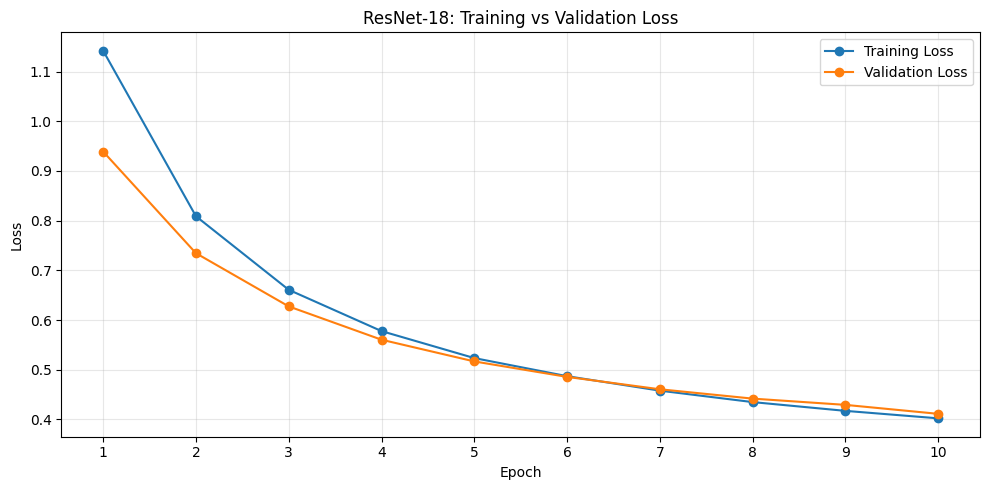

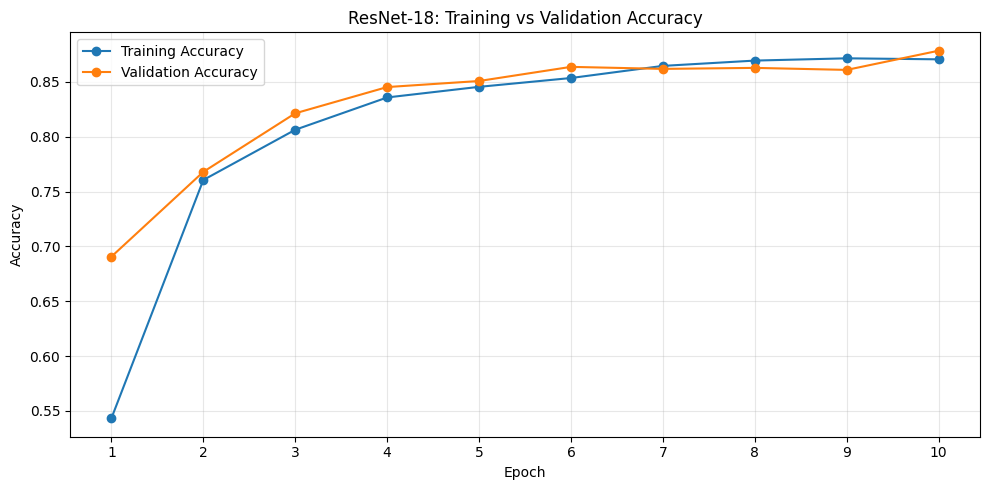

In [8]:
import matplotlib.pyplot as plt

epochs = range(1, len(history["train_loss"]) + 1)

# Training vs validation loss
plt.figure(figsize=(10, 5))

plt.plot(
    epochs,
    history["train_loss"],
    marker="o",
    label="Training Loss"
)

plt.plot(
    epochs,
    history["val_loss"],
    marker="o",
    label="Validation Loss"
)

plt.title("ResNet-18: Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.xticks(list(epochs))
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


# Training vs validation accuracy
plt.figure(figsize=(10, 5))

plt.plot(
    epochs,
    history["train_accuracy"],
    marker="o",
    label="Training Accuracy"
)

plt.plot(
    epochs,
    history["val_accuracy"],
    marker="o",
    label="Validation Accuracy"
)

plt.title("ResNet-18: Training vs Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.xticks(list(epochs))
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [10]:
import torch
import torch.nn as nn
from torchvision import models
from pathlib import Path

# Get class names directly from the test dataset
class_names = test_dataset.classes

# ResNet-18 checkpoint
resnet_checkpoint_path = Path(
    "../results/checkpoints/resnet18_best.pth"
)

# Create ResNet-18 architecture
resnet_model = models.resnet18(weights=None)

# Replace final classification layer
resnet_model.fc = nn.Linear(
    resnet_model.fc.in_features,
    4
)

# Load trained checkpoint
resnet_checkpoint = torch.load(
    resnet_checkpoint_path,
    map_location=device
)

resnet_model.load_state_dict(
    resnet_checkpoint["model_state_dict"]
)

# Move model to device
resnet_model = resnet_model.to(device)

# Evaluation mode
resnet_model.eval()

print("===== RESNET-18 LOADED =====")
print("Device:", device)
print("Test images:", len(test_dataset))
print("Classes:", class_names)

print(
    "Checkpoint validation accuracy:",
    resnet_checkpoint["best_val_accuracy"]
)

print(
    "Checkpoint epoch:",
    resnet_checkpoint["epoch"]
)

print("\nResNet-18 loaded successfully!")

===== RESNET-18 LOADED =====
Device: cpu
Test images: 1584
Classes: ['glioma', 'meningioma', 'notumor', 'pituitary']
Checkpoint validation accuracy: 0.8784530386740331
Checkpoint epoch: 10

ResNet-18 loaded successfully!


In [11]:
import numpy as np
import time
from torch.utils.data import DataLoader

# Reuse the same test dataset and loader
test_loader = DataLoader(
    test_dataset,
    batch_size=16,
    shuffle=False,
    num_workers=0
)

resnet_predictions = []
resnet_labels = []
resnet_probabilities = []

resnet_model.eval()
start_time = time.time()

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)

        outputs = resnet_model(images)
        probabilities = torch.softmax(outputs, dim=1)
        predictions = torch.argmax(probabilities, dim=1)

        resnet_predictions.extend(predictions.cpu().numpy())
        resnet_labels.extend(labels.numpy())
        resnet_probabilities.extend(probabilities.cpu().numpy())

resnet_predictions = np.array(resnet_predictions)
resnet_labels = np.array(resnet_labels)
resnet_probabilities = np.array(resnet_probabilities)

elapsed_time = time.time() - start_time

print("ResNet-18 test prediction completed!")
print("Images evaluated:", len(resnet_labels))
print(f"Prediction time: {elapsed_time:.2f} seconds")
print("Prediction shape:", resnet_predictions.shape)
print("Probability shape:", resnet_probabilities.shape)

ResNet-18 test prediction completed!
Images evaluated: 1584
Prediction time: 90.90 seconds
Prediction shape: (1584,)
Probability shape: (1584, 4)


In [12]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

# Calculate overall metrics
resnet_accuracy = accuracy_score(
    resnet_labels,
    resnet_predictions
)

resnet_precision = precision_score(
    resnet_labels,
    resnet_predictions,
    average="weighted"
)

resnet_recall = recall_score(
    resnet_labels,
    resnet_predictions,
    average="weighted"
)

resnet_f1 = f1_score(
    resnet_labels,
    resnet_predictions,
    average="weighted"
)

print("===== RESNET-18 FINAL TEST PERFORMANCE =====")

print(
    f"Test Accuracy : {resnet_accuracy:.4f} "
    f"({resnet_accuracy * 100:.2f}%)"
)

print(f"Test Precision: {resnet_precision:.4f}")
print(f"Test Recall   : {resnet_recall:.4f}")
print(f"Test F1-score : {resnet_f1:.4f}")

print("\n===== RESNET-18 CLASSIFICATION REPORT =====")

print(
    classification_report(
        resnet_labels,
        resnet_predictions,
        target_names=class_names,
        digits=4
    )
)

===== RESNET-18 FINAL TEST PERFORMANCE =====
Test Accuracy : 0.8188 (81.88%)
Test Precision: 0.8230
Test Recall   : 0.8188
Test F1-score : 0.8152

===== RESNET-18 CLASSIFICATION REPORT =====
              precision    recall  f1-score   support

      glioma     0.8885    0.6606    0.7578       386
  meningioma     0.6959    0.7186    0.7070       398
     notumor     0.8319    0.9775    0.8989       400
   pituitary     0.8774    0.9125    0.8946       400

    accuracy                         0.8188      1584
   macro avg     0.8234    0.8173    0.8146      1584
weighted avg     0.8230    0.8188    0.8152      1584



ResNet-18 Confusion Matrix:
[[255  89  30  12]
 [ 25 286  49  38]
 [  2   6 391   1]
 [  5  30   0 365]]


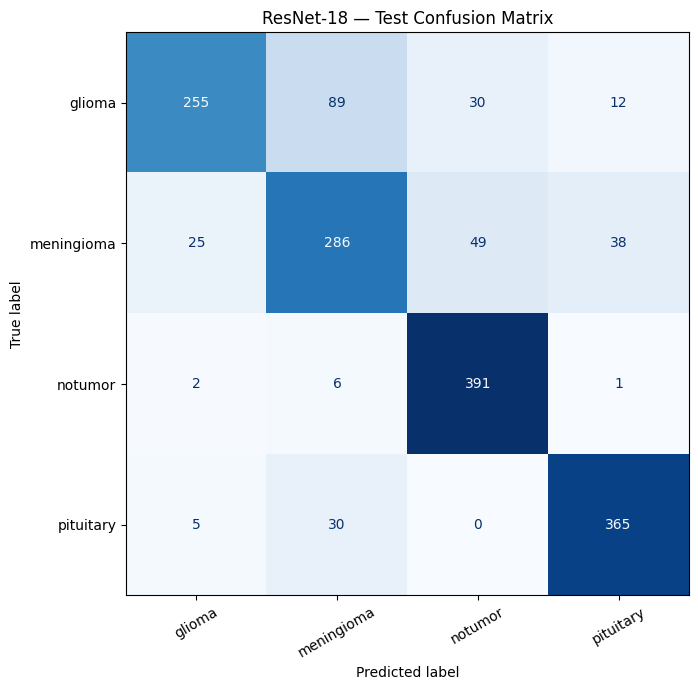

In [13]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

class_names = test_dataset.classes

resnet_cm = confusion_matrix(
    resnet_labels,
    resnet_predictions,
    labels=list(range(len(class_names)))
)

print("ResNet-18 Confusion Matrix:")
print(resnet_cm)

disp = ConfusionMatrixDisplay(
    confusion_matrix=resnet_cm,
    display_labels=class_names
)

fig, ax = plt.subplots(figsize=(8, 7))

disp.plot(
    ax=ax,
    cmap="Blues",
    values_format="d",
    colorbar=False
)

plt.title("ResNet-18 — Test Confusion Matrix")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

In [14]:
import json
from pathlib import Path
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

# Results directory
results_dir = Path("../results/metrics")
results_dir.mkdir(parents=True, exist_ok=True)

# Calculate final metrics
resnet_final_metrics = {
    "model": "ResNet-18",
    "checkpoint_epoch": int(resnet_checkpoint["epoch"]),
    "test_samples": int(len(resnet_labels)),
    "correct_predictions": int(
        (resnet_labels == resnet_predictions).sum()
    ),
    "misclassified_predictions": int(
        (resnet_labels != resnet_predictions).sum()
    ),
    "test_accuracy": float(
        accuracy_score(resnet_labels, resnet_predictions)
    ),
    "weighted_precision": float(
        precision_score(
            resnet_labels,
            resnet_predictions,
            average="weighted"
        )
    ),
    "weighted_recall": float(
        recall_score(
            resnet_labels,
            resnet_predictions,
            average="weighted"
        )
    ),
    "weighted_f1_score": float(
        f1_score(
            resnet_labels,
            resnet_predictions,
            average="weighted"
        )
    ),
    "macro_f1_score": float(
        f1_score(
            resnet_labels,
            resnet_predictions,
            average="macro"
        )
    ),
    "class_names": class_names,
    "confusion_matrix": confusion_matrix(
        resnet_labels,
        resnet_predictions,
        labels=list(range(len(class_names)))
    ).tolist(),
    "classification_report": classification_report(
        resnet_labels,
        resnet_predictions,
        target_names=class_names,
        output_dict=True
    )
}

# Save JSON file
output_path = results_dir / "resnet18_test_results.json"

with open(output_path, "w") as f:
    json.dump(resnet_final_metrics, f, indent=4)

print("ResNet-18 evaluation results saved!")
print("File:", output_path.resolve())
print(
    "Test accuracy:",
    f"{resnet_final_metrics['test_accuracy'] * 100:.2f}%"
)
print(
    "Correct predictions:",
    resnet_final_metrics["correct_predictions"]
)
print(
    "Misclassified predictions:",
    resnet_final_metrics["misclassified_predictions"]
)

ResNet-18 evaluation results saved!
File: D:\Projects\Medexplain_AI\ml\results\metrics\resnet18_test_results.json
Test accuracy: 81.88%
Correct predictions: 1297
Misclassified predictions: 287
